In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
# Only the project root goes on sys.path. py_files modules use relative imports
# (e.g. `from .data import ...`), so they must be imported package-qualified as
# `py_files.<module>` — never as bare `metrics` / `data` / `train`.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import importlib
from py_files import GallenModel_v1, Landslidev2_Old, metrics, train, data
importlib.reload(GallenModel_v1)
importlib.reload(Landslidev2_Old)
importlib.reload(data)
importlib.reload(metrics)
importlib.reload(train)
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
import geopandas as gpd
import seaborn as sns
import pandas as pd
import contextily as cx

from py_files.data import dataframe_to_dataset
from py_files.metrics import (
    plot_distribution,
    plot_susceptibility_map,
    plot_landslide_distribution,
    plot_confusion_matrix,
    plot_predicted_observed_map,
    calculate_distribution,
    rasterize_to_geotiff,
)

In [ ]:
#Load Data
training_df = gpd.read_file('~/Documents/ml-prep/ML-PREP-2025/learn/data/SU_16_Training.gpkg')
training_df.drop(columns=['landslide_probability', 'landslide_preds', 'confusion', 'sus_pinn_landslide', 'sus_pinn_ground truth', 'ds', 'cohesion', 'internal_friction', 'Landslide1', 'descriptio'], inplace=True)
print(training_df.columns)

training_df = training_df[training_df['Slope_mean'] > 10]


/Users/giogonzales/Documents/ml-prep/ML-PREP-2025/venv/lib/python3.10/site-packages/pyogrio/geopandas.py:275: UserWarning: More than one layer found in 'SU_16_Training.gpkg': 'zonal_statistics' (default), 'places'. Specify layer parameter to avoid this warning.
  result = read_func(


Index(['DN', 'BD_mean', 'Clay_mean', 'Sand_mean', 'Silt_mean', 'NDVI_mean',
       'Est_mean', 'Nrt_mean', 'HorCurv_mean', 'VertCurv_mean', 'Slope_mean',
       'Elev_mean', 'SoilThc_mean', 'DistFlt_min', 'LULC_majority', 'TWI_mean',
       'PGA2_max', 'PGA1_max', 'Prc_mean', 'Distrv_min', 'distrd_min',
       'Soil Type', 'BUK_mean', 'landslide', 'type', 'geometry'],
      dtype='object')


In [ ]:
# NOTE: 'type' is dropped because the SMOTE model (historical/v3/fold-10) takes
# 'Soil Type' as its categorical input, not 'type'. 'type' also doesn't exist in
# the validation gpkg (SU_15_Validation.gpkg), so keeping it would break
# validation_df[columns]. Remaining cols = 20 model inputs + 'landslide' target.
columns_to_remove = ['DN', 'BD_mean', 'geometry', 'PGA2_max', 'type']
columns = list(training_df.columns)

columns = [col for col in columns if col not in columns_to_remove]
training_df[columns].head()

In [ ]:
#Encode soil type into numeric
training_df.dropna(inplace=True)
training_df['Soil Type'], soil_code = pd.factorize(training_df['Soil Type'])

In [ ]:
#Transform data
training_ds = dataframe_to_dataset(training_df[columns], shuffle=False)

In [ ]:
#Load Model
model = load_model("/Users/giogonzales/Documents/ml-prep/ML-PREP-2025/learn/trainedWeights/trainedCotabatoPhase7/historical/v3/fold-10-model-0.keras")

In [ ]:
predicted_susceptibility = model.predict(training_ds)
training_df['predicted_susceptibility'] = predicted_susceptibility

1778/1778 ━━━━━━━━━━━━━━━━━━━━ 1s 638us/step


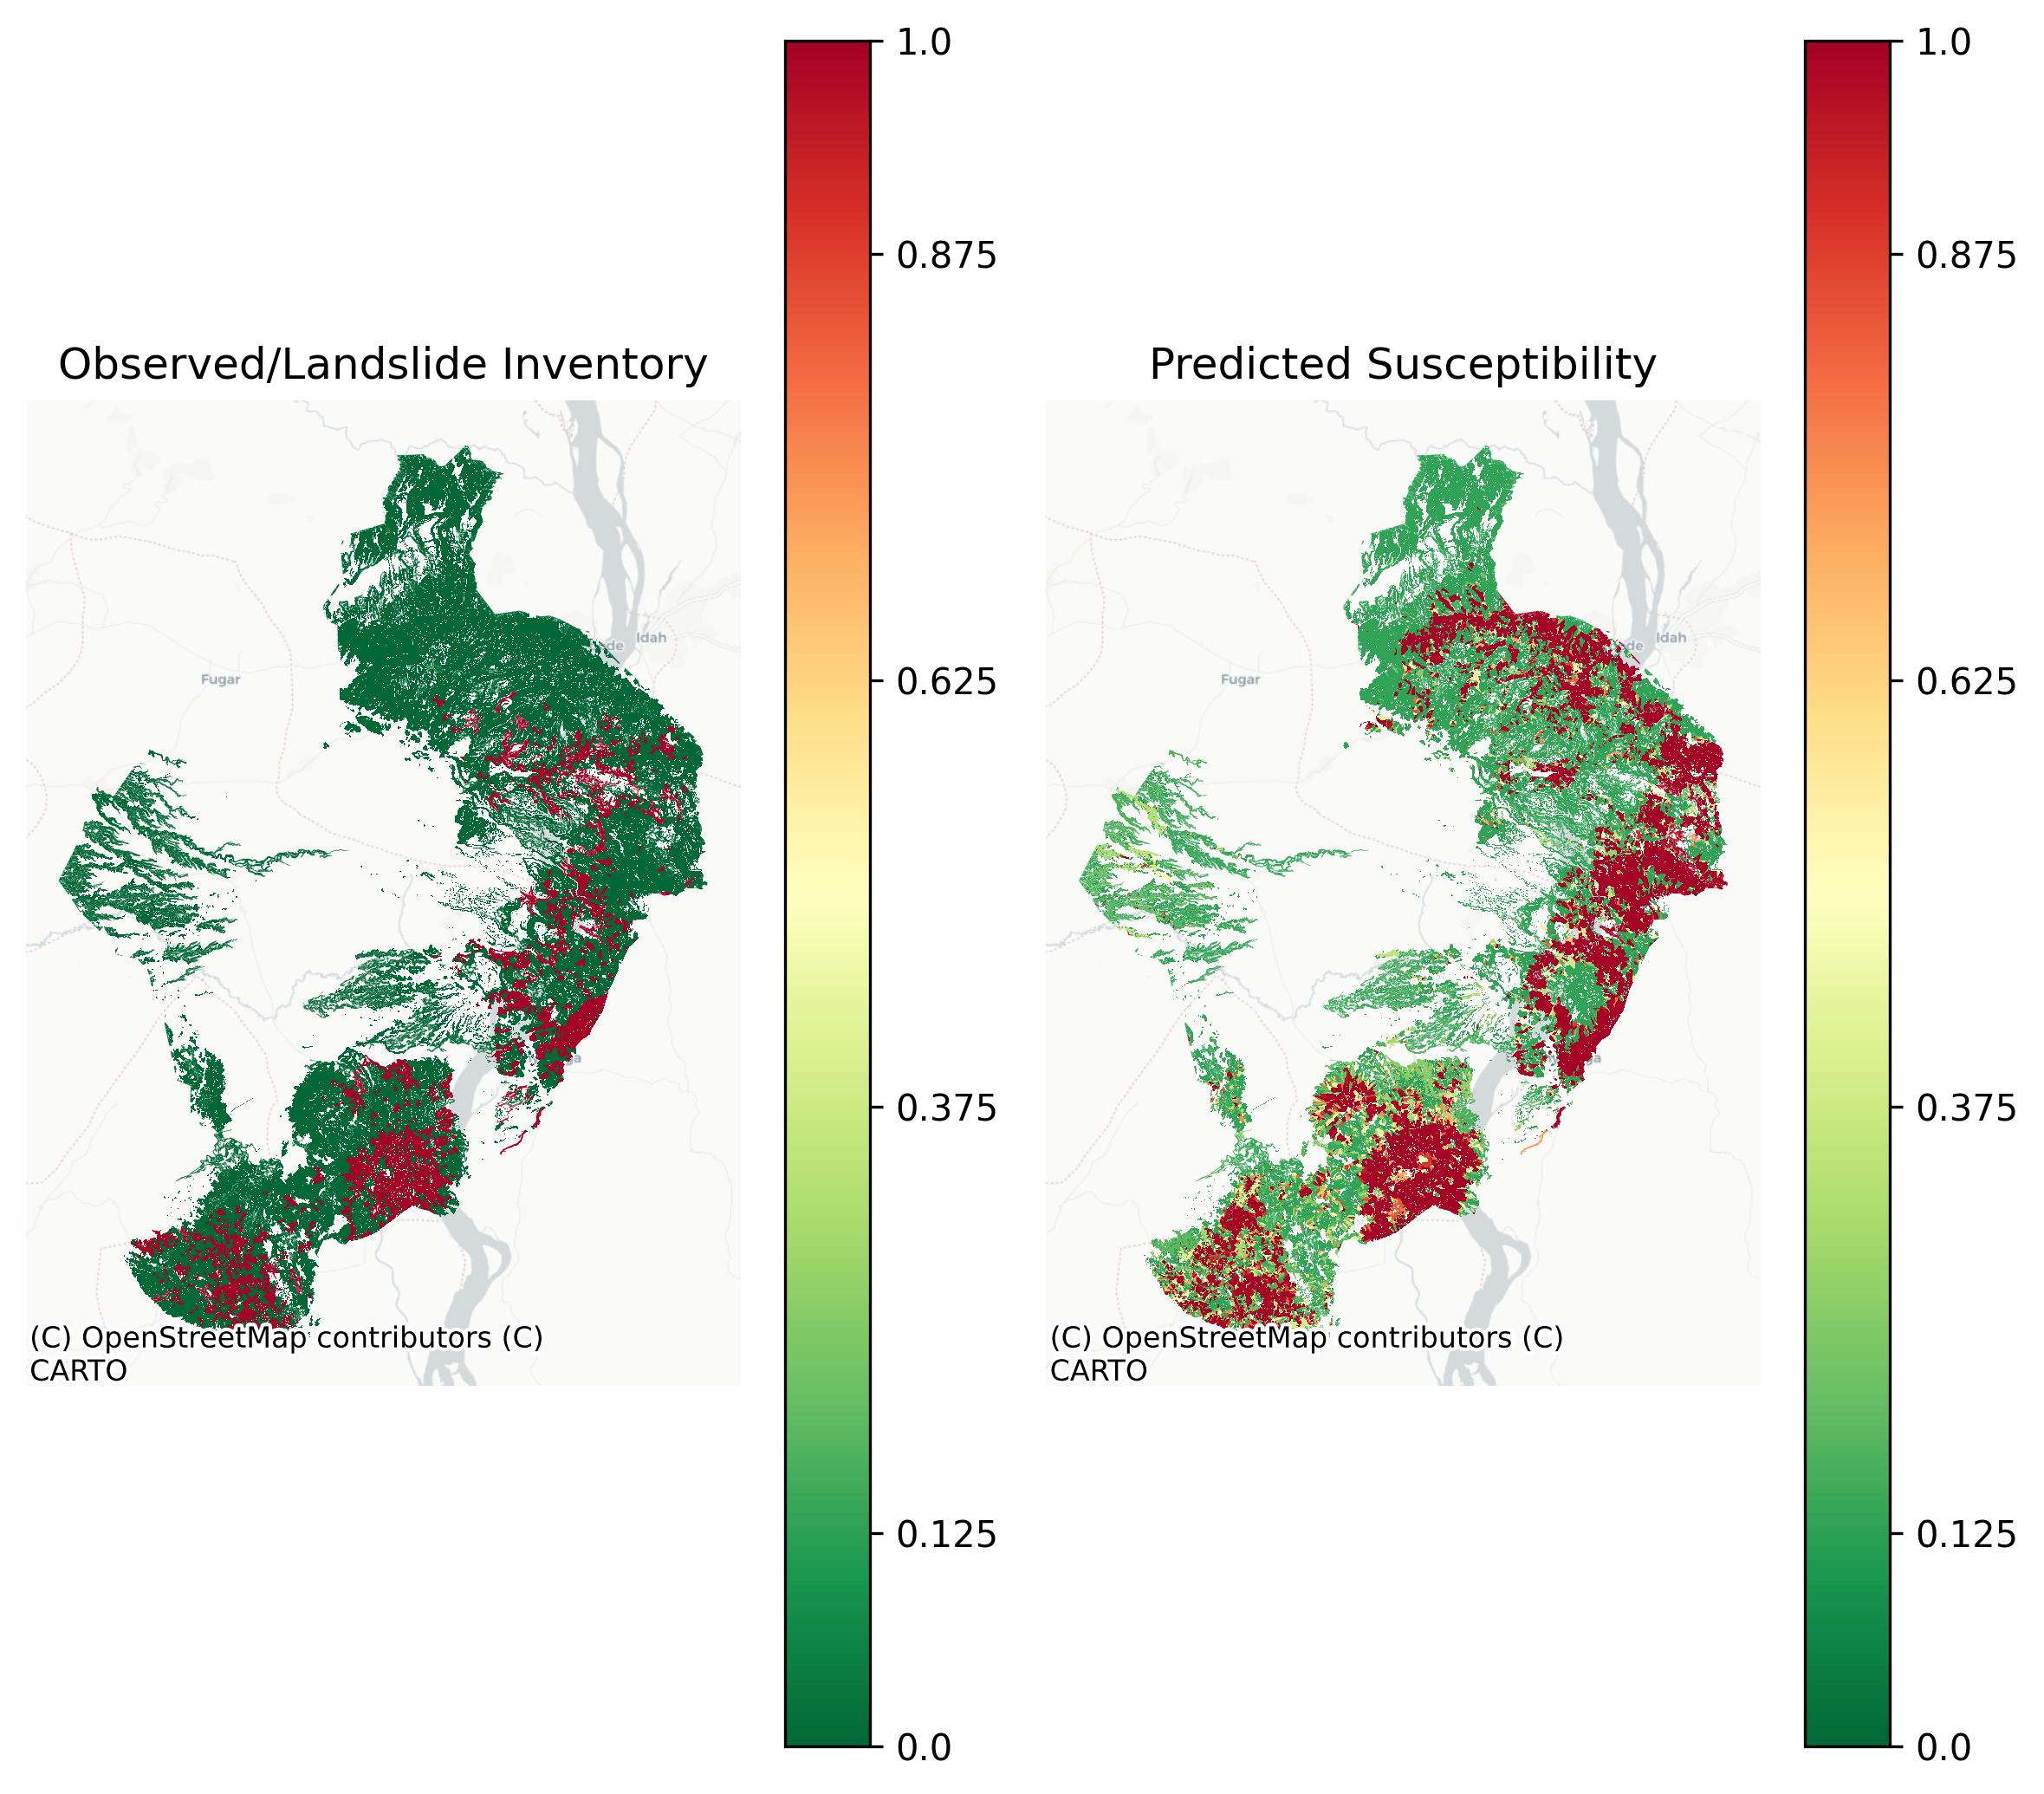

In [ ]:
# plot_susceptibility_map(training_df, predicted_susceptibility, 'Predicted Susceptibility Map - New Slope Unit v2 Model')
plot_predicted_observed_map(training_df, 'predicted_susceptibility', 'landslide')

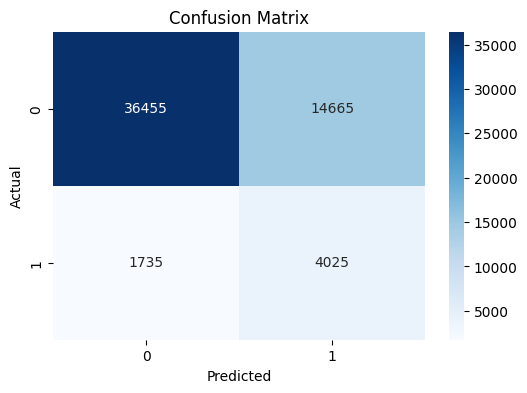

In [ ]:
plot_confusion_matrix(predicted_susceptibility, training_df['landslide'])

In [ ]:
import shap
def df_to_dict(df):
    return {
        col: df[col].values for col in columns if col != 'landslide'
    }
def df_to_input_list(df):
    return [df[col].values.reshape(-1, 1) for col in columns if col != 'landslide']
def df_to_input_list_multi(df):
    inputs = []
    for inp in model.input:
        name = inp.name.split(":")[0]

        col = df[name].values.reshape(-1, 1)

        if inp.dtype == tf.string:
            # categorical input: convert to string
            col = col.astype(str)
        else:
            # numeric input: convert to float32
            col = col.astype(np.float32)

        inputs.append(col)

    return inputs

feature_names = [col for col in columns if col != 'landslide']

background_inputs = df_to_input_list_multi(training_df.sample(100, random_state=42))
test_inputs = df_to_input_list_multi(training_df)

print(len(training_df))
print(np.array(background_inputs).shape)
print(np.array(test_inputs).shape)
print(len(columns))
explainer = shap.GradientExplainer(model=model, data=background_inputs)

# Compute SHAP values for test data
shap_values = explainer.shap_values(test_inputs)
X_test = training_df[feature_names].to_numpy()


/Users/giogonzales/Documents/ml-prep/ML-PREP-2025/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


56880
(20, 100, 1)
(20, 56880, 1)
22


In [ ]:
# Plot summary plot
shap_values = np.array(shap_values)
shap_values = np.squeeze(shap_values)   # removes extra (1,1) dims
shap_values = shap_values.T
print(shap_values.ndim, shap_values.shape)
print(len(feature_names))
shap.summary_plot(shap_values, X_test, feature_names=feature_names)
plt.tight_layout()
# plt.savefig(f'/Users/giogonzales/Documents/ml-prep/ML-PREP-2025/learn/figures/v2/historical/pinn-phase7-feature-importance.png', format="png")


2 (56880, 20)
21


/var/folders/dz/wrg2699d4jq7zd26swc8s2wm0000gn/T/ipykernel_5024/1828450058.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=feature_names)


AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

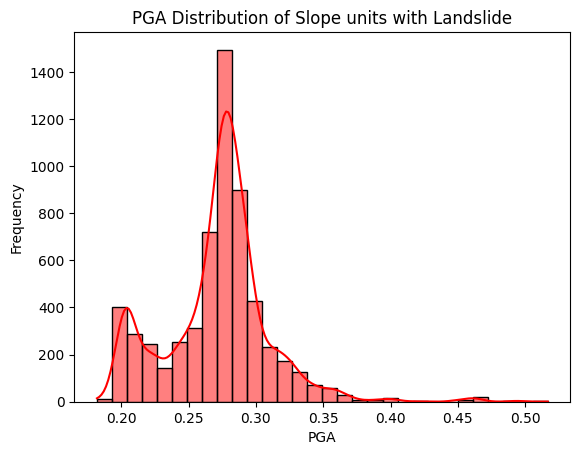

In [ ]:
filtered_pga_df = training_df[training_df['landslide'] == 1]
plot_distribution(filtered_pga_df, 'PGA Distribution of Slope units with Landslide', 'PGA', 'Frequency', 'PGA1_max')

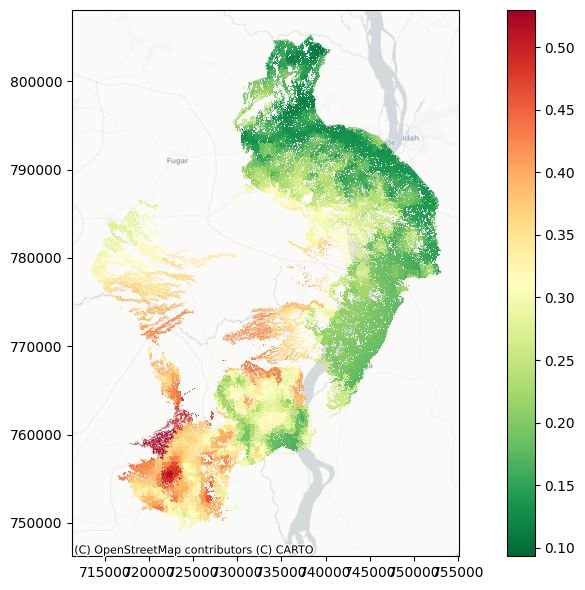

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
training_df.plot(column='PGA2_max', cmap='RdYlGn_r', legend=True, ax=ax)
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
plt.tight_layout()
plt.show()


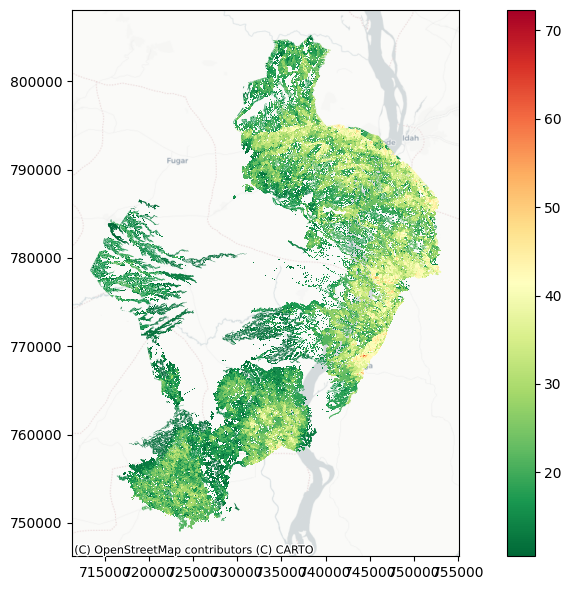

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
training_df.plot(column='Slope_mean', cmap='RdYlGn_r', legend=True, ax=ax)
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
plt.tight_layout()
plt.show()


In [ ]:
#Load Validation data for cohesion prediction
validation_df = gpd.read_file('~/Documents/ml-prep/ML-PREP-2025/learn/data/SU_15_Validation.gpkg')
validation_df = validation_df[validation_df['Slope_mean'] > 10]
validation_df.dropna(inplace=True)
validation_df['Soil Type'], _ = pd.factorize(validation_df['Soil Type'])

In [ ]:
validation_ds = dataframe_to_dataset(validation_df[columns], shuffle=False)

In [ ]:
predicted_susceptibility_validation = model.predict(validation_ds)

7797/7797 ━━━━━━━━━━━━━━━━━━━━ 5s 637us/step


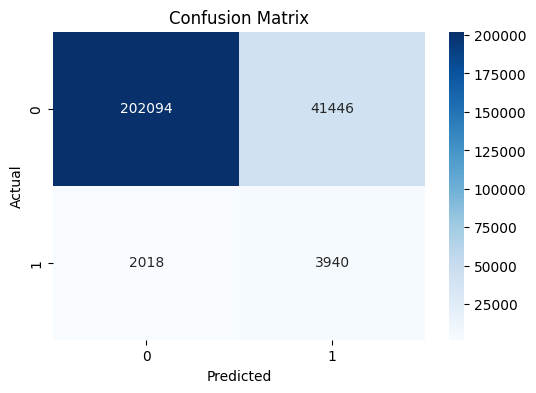

In [ ]:
plot_confusion_matrix(predicted_susceptibility_validation, validation_df['landslide'])

In [ ]:
# Visual figure (RGB picture, for slides/papers)
plot_susceptibility_map(validation_df, predicted_susceptibility_validation, "PINN SMOTE")

# True georeferenced raster: single-band float GeoTIFF with the polygons'
# susceptibility values burned into 30 m pixels (CRS = PRS92 UTM 51N).
# Model = historical/v3/fold-10-model-0.keras  ==> this is the PINN-SMOTE variant.
rasterize_to_geotiff(
    validation_df,
    np.ravel(predicted_susceptibility_validation),
    "../figures/v2_validation_smote_susceptibility.tif",
    pixel_size=30.0,
    layer_name="predicted_susceptibility",
)

7797/7797 ━━━━━━━━━━━━━━━━━━━━ 5s 633us/step
Predicted cohesion length: 249498


(np.float32(0.0), np.float32(1.938006))

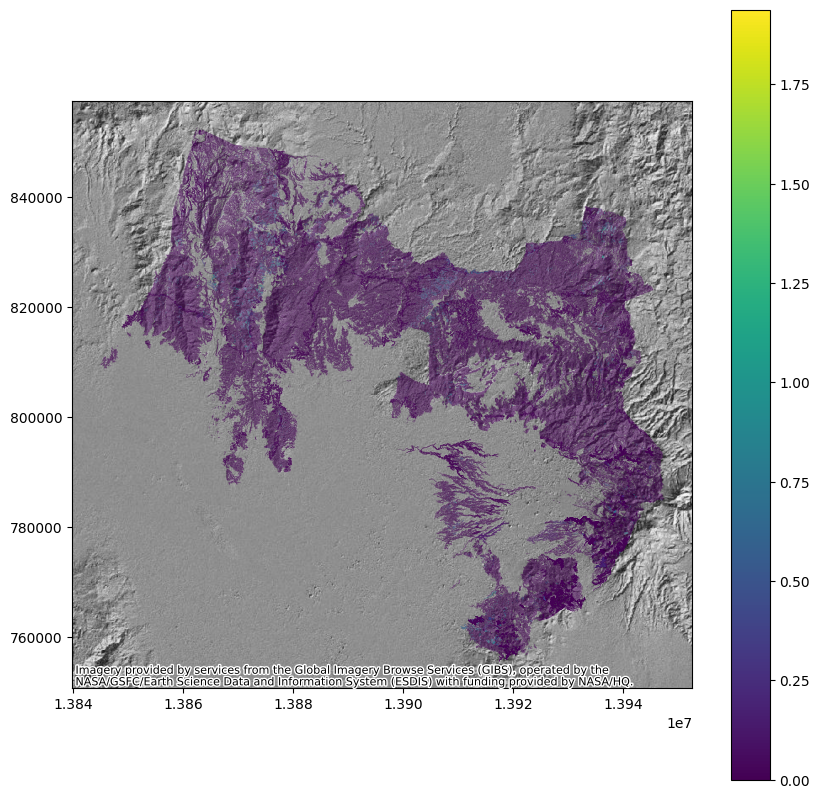

In [ ]:
#Extract Geotechnical estimation of the model
df_wm = validation_df.to_crs(epsg=3857)
cohesion_model = tf.keras.Model(inputs=model.inputs, outputs=model.get_layer("cohesion_layer").output)
predicted_cohesion = cohesion_model.predict(validation_ds)
df_wm['estimated_cohesion'] = predicted_cohesion

ax = df_wm.plot(column="estimated_cohesion", legend=True, figsize=(10, 10), alpha=0.7)
cx.add_basemap(ax,source='NASAGIBS.ASTER_GDEM_Greyscale_Shaded_Relief')
print(f"Predicted cohesion length: {len(predicted_cohesion)}")
df_wm['estimated_cohesion'].min(), df_wm['estimated_cohesion'].max()


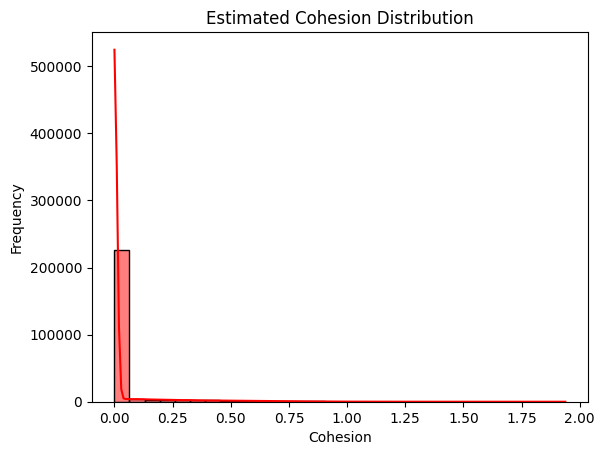

In [ ]:
plot_distribution(df_wm, "Estimated Cohesion Distribution", "Cohesion", "Frequency", "estimated_cohesion")

7797/7797 ━━━━━━━━━━━━━━━━━━━━ 5s 655us/step


(np.float32(0.41942355), np.float32(1.0))

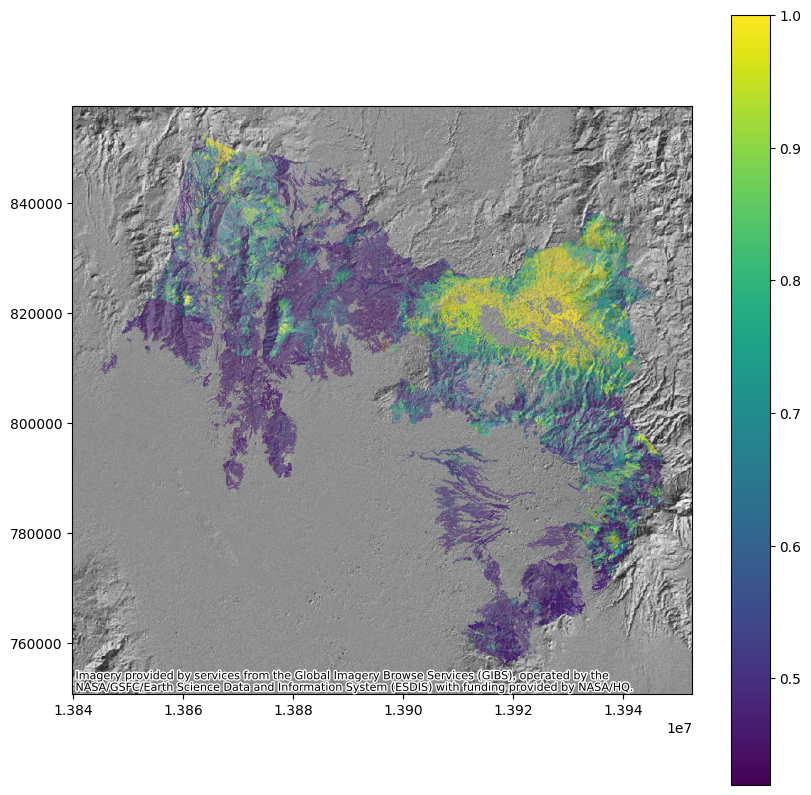

In [ ]:
#Extract Geotechnical estimation of the model
df_wm = validation_df.to_crs(epsg=3857)
friction_model = tf.keras.Model(inputs=model.inputs, outputs=model.get_layer("internal_friction").output)
predicted_friction = friction_model.predict(validation_ds)
df_wm['estimated_friction'] = predicted_friction

ax = df_wm.plot(column="estimated_friction", legend=True, figsize=(10, 10), alpha=0.7)
cx.add_basemap(ax,source='NASAGIBS.ASTER_GDEM_Greyscale_Shaded_Relief')

df_wm['estimated_friction'].min(), df_wm['estimated_friction'].max()


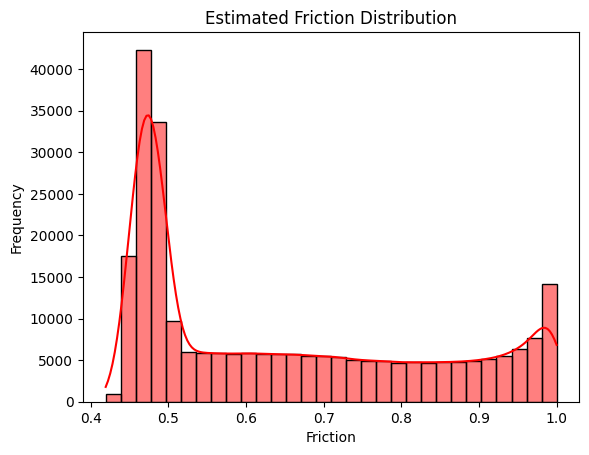

In [ ]:
plot_distribution(df_wm, "Estimated Friction Distribution", "Friction", "Frequency", "estimated_friction")

In [ ]:
result = calculate_distribution(validation_df)
print(result)

{'0.125': 162527, '0.375': 38260, '0.625': 206574, '0.875': 4399, '1.0': 10691}
